# Working with precipitation and temperature monthly values

You will need to:
- Import modules that are important to complete the work.
- Load the files and "understand" them.
- Join the files in a large matrix.
- Compute statistics.
- Save the files for later use.

Optionally:
- Create plots

### Do not forget to run all cells in order, from top to bottom. Failing to do so may cause errors.
### AI Large Language Models (such as deepseek) can help you a lot doing this.

## Modules

Some useful modules are:
- `pandas` (https://pandas.pydata.org/docs/getting_started/intro_tutorials/): to work with tabular data (including import and export). It is the "Microsoft Excel" of Python.
- `matplotlib` (https://matplotlib.org/stable/plot_types/index.html): to create figures (plots).
- `pathlib`: not as important. To handle folder and file paths.

## Import modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
file_path = Path(r'./Lab work/6606347/precipitation/UKE00105909.csv')

## Now let's read it with pandas

It is really this easy!

Check out the documentation here:
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

In [3]:
pd.read_csv(file_path)

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,PRCP_ATTRIBUTES,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES
0,UKE00105909,1959-12-31,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,NaN,111.0,",,E",NaN,NaN
1,UKE00105909,1960-01-01,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,NaN,67.0,",I,E",94.0,",I,E"
2,UKE00105909,1960-01-02,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,NaN,106.0,",,E",44.0,",,E"
3,UKE00105909,1960-01-03,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,NaN,122.0,",,E",56.0,",,E"
4,UKE00105909,1960-01-04,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,NaN,78.0,",,E",56.0,",,E"
...,...,...,...,...,...,...,...,...,...,...,...,...
23376,UKE00105909,2025-01-27,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",48.0,",,E",89.0,",,E",38.0,",,E"
23377,UKE00105909,2025-01-28,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",16.0,",,E",78.0,",,E",47.0,",,E"
23378,UKE00105909,2025-01-29,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",0.0,",,E",79.0,",,E",21.0,",,E"
23379,UKE00105909,2025-01-30,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",48.0,",,E",80.0,",,E",-4.0,",,E"


## We can provide more information to the reader too
I wish to use the date as the row index.  
To parse the dates correctly as `datetime64[ns]` we use the `pd.to_datetime` function.   
    You can find all about the format here: https://docs.python.org/3/library/datetime.html#strftime-and-strptime-behavior   
We also want to discard all columns beyond PRCP (precipitation)

### Precipitation data from this source (GHCN-Daily) is stored in 0.1 mm/day. We must convert to mm/day.
### Something similar happens with temprature
### Mean temperature cas be calculated as the average of the Maximum and the Minimum

In [4]:
my_data = pd.read_csv(file_path, index_col=1, usecols=[0, 1, 2, 3, 4, 5, 6, 8, 10])
my_data.index = pd.to_datetime(my_data.index, format='%Y-%m-%d', errors='coerce')
my_data.iloc[:, 5] /= 10
my_data.iloc[:, -2:] /= 10
my_data.loc[:, 'TMEAN']  = (my_data.TMAX + my_data.TMIN) / 2

station = my_data.iloc[0, 0]
print(f'This station is {station}')

my_data

This station is UKE00105909


,STATION,LATITUDE,LONGITUDE,ELEVATION,NAME,PRCP,TMAX,TMIN,TMEAN
DATE,,,,,,,,,
1959-12-31,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,11.1,NaN,NaN
1960-01-01,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,6.7,9.4,8.05
1960-01-02,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,10.6,4.4,7.50
1960-01-03,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,12.2,5.6,8.90
1960-01-04,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",NaN,7.8,5.6,6.70
...,...,...,...,...,...,...,...,...,...
2025-01-27,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",4.8,8.9,3.8,6.35
2025-01-28,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",1.6,7.8,4.7,6.25
2025-01-29,UKE00105909,52.2058,-1.6031,47.0,"WELLESBOURNE, UK",0.0,7.9,2.1,5.00


## Let's see what the data looks like
Using matplotlib (included in pandas).  
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html

<Axes: xlabel='DATE'>

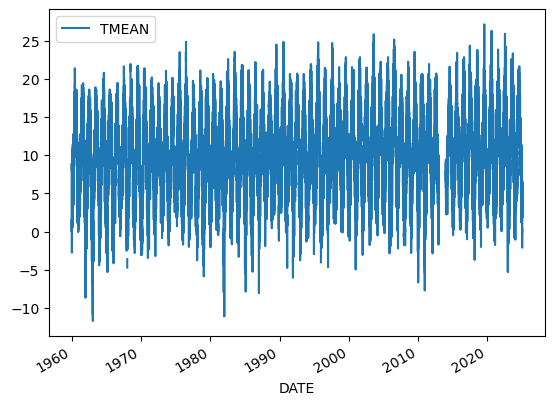

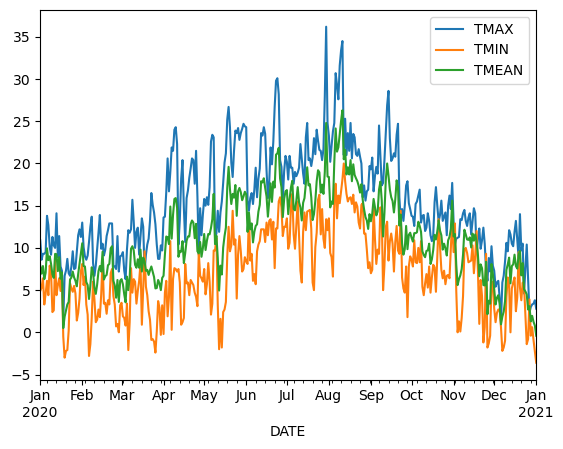

In [5]:
my_data.iloc[:, -1:].plot()
my_data.loc['2020-01-01':'2021-01-01', :].iloc[:, -3:].plot()

In [6]:
monthly_temperature_data = my_data.loc[:, ['TMAX', 'TMIN', 'TMEAN']].resample('MS').mean().dropna()
monthly_temperature_data.tail(5)

,TMAX,TMIN,TMEAN
DATE,,,
2024-09-01,18.253333,10.260000,14.256667
2024-10-01,15.361290,7.903226,11.632258
2024-11-01,10.633333,4.313333,7.473333
2024-12-01,9.274194,4.619355,6.946774
2025-01-01,6.253333,0.019355,3.130000


In [7]:
monthly_precipitation_data = my_data.loc[:, ['PRCP']].resample('MS').mean().dropna()
monthly_precipitation_data.tail(5)

,PRCP
DATE,
2024-09-01,3.933333
2024-10-01,2.000000
2024-11-01,2.013333
2024-12-01,1.916129
2025-01-01,2.148387


## Now just save them to excel or csv files
Do it with `pd.to_excel()` or `pd.to_csv()`

In [8]:
folder_path = Path(r'./Lab work/6606347/precipitation')
for file in folder_path.glob('*.csv'):
    print(file)

Lab work\6606347\precipitation\UK000056225.csv
Lab work\6606347\precipitation\UKE00102158.csv
Lab work\6606347\precipitation\UKE00105869.csv
Lab work\6606347\precipitation\UKE00105909.csv
Lab work\6606347\precipitation\UKE00105911.csv
Lab work\6606347\precipitation\UKE00105915.csv
Lab work\6606347\precipitation\UKE00105922.csv
Lab work\6606347\precipitation\UKE00105923.csv
Lab work\6606347\precipitation\UKE00105924.csv
Lab work\6606347\precipitation\UKE00105925.csv
Lab work\6606347\precipitation\UKE00107650.csv
Lab work\6606347\precipitation\UKE00107962.csv
Lab work\6606347\precipitation\UKM00003740.csv
Lab work\6606347\precipitation\UKM00003772.csv
Lab work\6606347\precipitation\UKM00003862.csv


In [9]:
all_data = []
for file in folder_path.glob('*.csv'):
    try:
        station = file.name.replace('.csv','')
        
        _data = pd.read_csv(file, index_col=1, usecols=[0, 1, 2, 3, 4, 5, 6, 8, 10])
        _data.index = pd.to_datetime(_data.index, format='%Y-%m-%d', errors='coerce')
        _data.iloc[:, 5] /= 10
        _data.iloc[:, -2:] /= 10
        _data.loc[:, 'TMEAN']  = (_data.TMAX + _data.TMIN) / 2
    
        monthly_data = my_data.loc[:, ['PRCP', 'TMAX', 'TMIN', 'TMEAN']].resample('MS').mean().dropna()
        monthly_data.columns = monthly_data.columns = pd.MultiIndex.from_product([['P [mm/day]', 'Tmax [C]', 'Tmin [C]', 'Tmean [C]'], [station]], names=['Variable', 'Station'])
        
        all_data.append(monthly_data)
    except Exception as ex:
        pass

full_dataset = pd.concat(all_data, axis=1)
full_dataset

Variable,P [mm/day],Tmax [C],Tmin [C],Tmean [C],P [mm/day],Tmax [C],Tmin [C],Tmean [C],P [mm/day],Tmax [C],...,Tmin [C],Tmean [C],P [mm/day],Tmax [C],Tmin [C],Tmean [C],P [mm/day],Tmax [C],Tmin [C],Tmean [C]
Station,UK000056225,UK000056225,UK000056225,UK000056225,UKE00105869,UKE00105869,UKE00105869,UKE00105869,UKE00105909,UKE00105909,...,UKE00105924,UKE00105924,UKE00105925,UKE00105925,UKE00105925,UKE00105925,UKE00107962,UKE00107962,UKE00107962,UKE00107962
DATE,,,,,,,,,,,,,,,,,,,,,
1961-01-01,1.554839,6.141935,0.738710,3.440323,1.554839,6.141935,0.738710,3.440323,1.554839,6.141935,...,0.738710,3.440323,1.554839,6.141935,0.738710,3.440323,1.554839,6.141935,0.738710,3.440323
1961-02-01,1.567857,10.275000,3.925000,7.100000,1.567857,10.275000,3.925000,7.100000,1.567857,10.275000,...,3.925000,7.100000,1.567857,10.275000,3.925000,7.100000,1.567857,10.275000,3.925000,7.100000
1961-03-01,0.070968,13.406452,2.235484,7.820968,0.070968,13.406452,2.235484,7.820968,0.070968,13.406452,...,2.235484,7.820968,0.070968,13.406452,2.235484,7.820968,0.070968,13.406452,2.235484,7.820968
1961-04-01,2.693333,14.076667,6.116667,10.096667,2.693333,14.076667,6.116667,10.096667,2.693333,14.076667,...,6.116667,10.096667,2.693333,14.076667,6.116667,10.096667,2.693333,14.076667,6.116667,10.096667
1961-05-01,0.600000,15.983871,5.577419,10.780645,0.600000,15.983871,5.577419,10.780645,0.600000,15.983871,...,5.577419,10.780645,0.600000,15.983871,5.577419,10.780645,0.600000,15.983871,5.577419,10.780645
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-01,3.933333,18.253333,10.260000,14.256667,3.933333,18.253333,10.260000,14.256667,3.933333,18.253333,...,10.260000,14.256667,3.933333,18.253333,10.260000,14.256667,3.933333,18.253333,10.260000,14.256667
2024-10-01,2.000000,15.361290,7.903226,11.632258,2.000000,15.361290,7.903226,11.632258,2.000000,15.361290,...,7.903226,11.632258,2.000000,15.361290,7.903226,11.632258,2.000000,15.361290,7.903226,11.632258


## Now save to excel or csv

In [ ]:
full_dataset.to_csv('monthly.csv')
full_dataset.to_excel('monthly.xlsx')